# Sentiment-Based Sorting — Merged Library Domain Notebook

Naive Bayes, Decision Tree, and a Naive Bayes -> Decision Tree hybrid.
Metrics: accuracy, F1-score, recall.

**Dataset:** `merged_library_dataset.csv` — 7,124 rows combining EduRABSA
(6,491 rows, general education reviews) with local six-category student
feedback (633 rows, including library facilities). Already merged and
deduplicated; this notebook loads it directly rather than rebuilding it
from the two original source files.

Columns: `text`, `sentiment` (positive/neutral/negative), `source`
(edurabsa or local), `category` (edurabsa, or one of the six local
categories including library_facilities).

Section 12 evaluates on the library-facilities rows specifically, since
that is the deployment target, not the merged average.

**Update (v3):** the notebook now loads `merged_library_dataset_v3.csv` = the v2 data plus 748 extra
Taglish/English rows (`source == 'local_taglish_aug'`) about staff behaviour, tables and seats, heat,
noise, cleanliness, wifi, computers and borrowing. Those rows are used for **training only**; the test
set is still the original rows, so scores stay comparable with earlier versions.
Naive Bayes is now **probability-calibrated** and the Decision Tree needs **at least 10 rows per leaf**, so the
percentages shown in the app are meaningful instead of almost always ~100%. The settings are at the top
of the setup cell and were chosen by 5-fold cross-validation on the training rows only.

## 1. Setup and load both datasets


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix
import joblib

RANDOM_STATE = 42

# ---- Model settings (chosen by 5-fold cross-validation on the TRAINING rows only) ----
NB_ALPHA = 0.3
NB_CALIBRATION = 'isotonic'   # calibrate Naive Bayes so its probabilities are not almost always ~100%
DT_MAX_DEPTH = None           # depth is not limited ...
DT_MIN_SAMPLES_LEAF = 10      # ... but leaves need >= 10 rows, so they are not pure (min_samples_leaf=2 gave ~100% almost everywhere)
HYBRID_THRESHOLD = 0.45       # Naive Bayes is trusted when its calibrated confidence is >= this, else the Decision Tree decides
AUG_SOURCE = 'local_taglish_aug'   # extra Taglish/English rows: training only, never in the test set


def make_nb():
    return CalibratedClassifierCV(MultinomialNB(alpha=NB_ALPHA), method=NB_CALIBRATION, cv=5)


def make_dt():
    return DecisionTreeClassifier(class_weight='balanced', max_depth=DT_MAX_DEPTH,
                                  min_samples_leaf=DT_MIN_SAMPLES_LEAF, random_state=RANDOM_STATE)

df = pd.read_csv('merged_library_dataset_v3.csv')

print('Shape:', df.shape)
print()
print(df['source'].value_counts())
print()
print(df['category'].value_counts())
print()
print(df['sentiment'].value_counts())
print()
df.head()


Shape: (8431, 4)

source
edurabsa             6491
local_taglish_aug     748
local                 633
local_library_aug     487
local_library          72
Name: count, dtype: int64

category
edurabsa              6491
library_facilities    1407
teaching               123
coursecontent          112
examination            102
labwork                100
extracurricular         96
Name: count, dtype: int64

sentiment
neutral     3943
positive    2964
negative    1524
Name: count, dtype: int64



,text,sentiment,source,category
0,He is not helpful at all and makes fun of stud...,negative,edurabsa,edurabsa
1,"This course was amazing. For the first time, t...",neutral,edurabsa,edurabsa
2,Exams were very easy and he allowed us to do e...,neutral,edurabsa,edurabsa
3,The lecturers from Exeter have helped me throu...,positive,edurabsa,edurabsa
4,"Extremely boring and lectures were useless, bu...",neutral,edurabsa,edurabsa


## 2. Clean the text


In [2]:
df = df.drop_duplicates(subset='text').reset_index(drop=True)

def preprocess(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())
    return ' '.join(text.split())

df['clean'] = df['text'].apply(preprocess)
df = df[df['clean'].str.len() > 0].reset_index(drop=True)
print('Rows after cleaning:', len(df))
print(df['source'].value_counts())


Rows after cleaning: 8429
source
edurabsa             6489
local_taglish_aug     748
local                 633
local_library_aug     487
local_library          72
Name: count, dtype: int64


## 3. Split into train and test

80/20, stratified by sentiment across the merged dataset. Stratifying by
sentiment alone (not by source) means the split may not preserve the exact
EduRABSA-to-local ratio in each class, but it guarantees all three
sentiment classes appear in both sets, which matters more given how small
the local negative and neutral classes are.

The extra Taglish/English rows (`AUG_SOURCE`) are added to the **training** set only, after the split, so
the test set stays the original rows and scores remain comparable with earlier versions of this notebook.

In [3]:
aug = df[df['source'] == AUG_SOURCE]
base = df[df['source'] != AUG_SOURCE]
train, test = train_test_split(
    base, test_size=0.20, stratify=base['sentiment'], random_state=RANDOM_STATE)
train = pd.concat([train, aug], ignore_index=True)   # augmentation rows are training-only

X_train, y_train = train['clean'], train['sentiment']
X_test,  y_test  = test['clean'],  test['sentiment']

vectorizer = CountVectorizer(ngram_range=(1, 2), min_df=2)
Xtr = vectorizer.fit_transform(X_train)
Xte = vectorizer.transform(X_test)

print('Train size:', Xtr.shape[0], '  Test size:', Xte.shape[0])
print('Test class counts:', y_test.value_counts().to_dict())
print('Test rows by source:', test['source'].value_counts().to_dict())
print('Library-facilities rows in test:', (test['category'] == 'library_facilities').sum())


Train size: 6892   Test size: 1537
Test class counts: {'neutral': 754, 'positive': 545, 'negative': 238}
Test rows by source: {'edurabsa': 1303, 'local': 114, 'local_library_aug': 102, 'local_library': 18}
Library-facilities rows in test: 135


## 4. Naive Bayes


In [4]:
nb = make_nb()
nb.fit(Xtr, y_train)
nb_pred = nb.predict(Xte)

print('Accuracy :', round(accuracy_score(y_test, nb_pred), 4))
print('F1-score :', round(f1_score(y_test, nb_pred, average='macro'), 4))
print('Recall   :', round(recall_score(y_test, nb_pred, average='macro'), 4))
print()
print(classification_report(y_test, nb_pred, digits=3))


Accuracy : 0.743
F1-score : 0.7028
Recall   : 0.6769

              precision    recall  f1-score   support

    negative      0.854     0.441     0.582       238
     neutral      0.727     0.817     0.770       754
    positive      0.743     0.772     0.757       545

    accuracy                          0.743      1537
   macro avg      0.774     0.677     0.703      1537
weighted avg      0.752     0.743     0.736      1537



## 5. Decision Tree


In [5]:
dt = make_dt()
dt.fit(Xtr, y_train)
dt_pred = dt.predict(Xte)

print('Accuracy :', round(accuracy_score(y_test, dt_pred), 4))
print('F1-score :', round(f1_score(y_test, dt_pred, average='macro'), 4))
print('Recall   :', round(recall_score(y_test, dt_pred, average='macro'), 4))
print()
print(classification_report(y_test, dt_pred, digits=3))


Accuracy : 0.6675
F1-score : 0.6401
Recall   : 0.6598

              precision    recall  f1-score   support

    negative      0.452     0.613     0.520       238
     neutral      0.770     0.649     0.704       754
    positive      0.675     0.717     0.696       545

    accuracy                          0.668      1537
   macro avg      0.632     0.660     0.640      1537
weighted avg      0.687     0.668     0.673      1537



## 6. Hybrid (Naive Bayes -> Decision Tree)

Naive Bayes classifies every review. Where its confidence is below the
threshold, the Decision Tree decides instead.

Naive Bayes is probability-calibrated (`CalibratedClassifierCV`) so its confidence is honest, and the
Decision Tree needs at least 10 rows per leaf, so its leaves are not all pure. Settings come from the setup cell.

In [6]:
class Hybrid(BaseEstimator, ClassifierMixin):
    def __init__(self, threshold=0.9, nb_alpha=0.3, calibration=None, max_depth=None, min_samples_leaf=2):
        self.threshold = threshold
        self.nb_alpha = nb_alpha
        self.calibration = calibration
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf

    def fit(self, X, y):
        nb = MultinomialNB(alpha=self.nb_alpha)
        self.nb_ = nb if self.calibration is None else CalibratedClassifierCV(nb, method=self.calibration, cv=5)
        self.nb_.fit(X, y)
        self.dt_ = DecisionTreeClassifier(class_weight='balanced', max_depth=self.max_depth,
                                          min_samples_leaf=self.min_samples_leaf,
                                          random_state=42).fit(X, y)
        return self

    def predict(self, X):
        proba = self.nb_.predict_proba(X)
        pred = self.nb_.predict(X).copy()
        low_confidence = proba.max(axis=1) < self.threshold
        if low_confidence.any():
            pred[low_confidence] = self.dt_.predict(X[low_confidence])
        return pred

def make_hybrid():
    return Hybrid(threshold=HYBRID_THRESHOLD, nb_alpha=NB_ALPHA, calibration=NB_CALIBRATION,
                  max_depth=DT_MAX_DEPTH, min_samples_leaf=DT_MIN_SAMPLES_LEAF)


hybrid = make_hybrid()
hybrid.fit(Xtr, y_train)
hybrid_pred = hybrid.predict(Xte)

print('Accuracy :', round(accuracy_score(y_test, hybrid_pred), 4))
print('F1-score :', round(f1_score(y_test, hybrid_pred, average='macro'), 4))
print('Recall   :', round(recall_score(y_test, hybrid_pred, average='macro'), 4))
print()
print(classification_report(y_test, hybrid_pred, digits=3))


Accuracy : 0.7495
F1-score : 0.7142
Recall   : 0.6904

              precision    recall  f1-score   support

    negative      0.820     0.479     0.605       238
     neutral      0.736     0.814     0.773       754
    positive      0.752     0.778     0.765       545

    accuracy                          0.750      1537
   macro avg      0.769     0.690     0.714      1537
weighted avg      0.755     0.750     0.744      1537



## 7. Compare all three


In [7]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Decision Tree', 'Hybrid'],
    'Accuracy': [accuracy_score(y_test, nb_pred),
                accuracy_score(y_test, dt_pred),
                accuracy_score(y_test, hybrid_pred)],
    'F1-score': [f1_score(y_test, nb_pred, average='macro'),
                f1_score(y_test, dt_pred, average='macro'),
                f1_score(y_test, hybrid_pred, average='macro')],
    'Recall':   [recall_score(y_test, nb_pred, average='macro'),
                recall_score(y_test, dt_pred, average='macro'),
                recall_score(y_test, hybrid_pred, average='macro')],
}).set_index('Model').round(4)

results


,Accuracy,F1-score,Recall
Model,,,
Naive Bayes,0.7430,0.7028,0.6769
Decision Tree,0.6675,0.6401,0.6598
Hybrid,0.7495,0.7142,0.6904


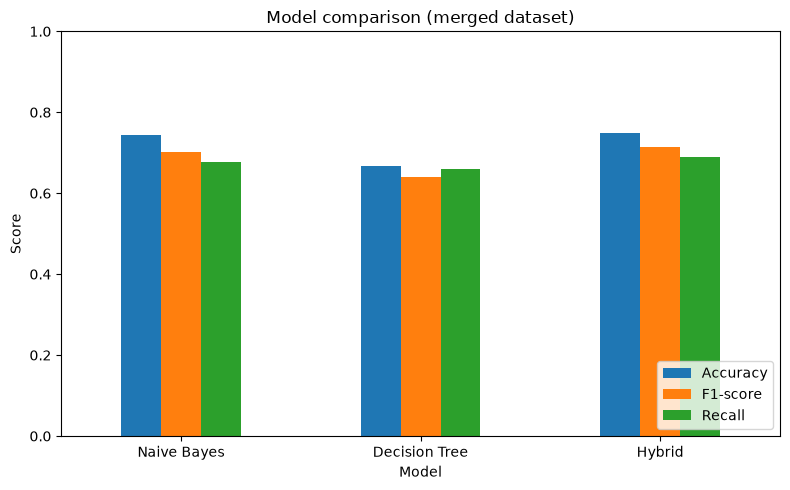

In [8]:
results.plot(kind='bar', figsize=(8, 5), rot=0)
plt.title('Model comparison (merged dataset)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 7b. How trustworthy are the percentages?

The Django dashboard shows each model's confidence. A confidence is only useful if it matches reality:
when a model says ~90% it should be right about 90% of the time. This compares the **average confidence**
with the **actual accuracy** (their gap is the expected calibration error, ECE; smaller is better), how often
the model claims >=99%, and how many clear mistakes (positive shown as negative or the reverse) each makes.

In [9]:
def calibration_report(name, proba, classes, y_true):
    y_true = np.asarray(y_true)
    conf = proba.max(axis=1)
    pred = classes[proba.argmax(axis=1)]
    correct = (pred == y_true).astype(float)
    edges = np.linspace(0, 1, 11)
    ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return {'Model': name, 'Mean confidence': conf.mean(), 'Accuracy': correct.mean(),
            'ECE (gap)': ece, 'Share claiming >=99%': (conf >= 0.99).mean()}


def polarity_flips(y_true, pred):
    y_true, pred = np.asarray(y_true), np.asarray(pred)
    return int(((y_true == 'positive') & (pred == 'negative')).sum() +
               ((y_true == 'negative') & (pred == 'positive')).sum())


classes_ = nb.classes_
conf_table = pd.DataFrame([
    calibration_report('Naive Bayes', nb.predict_proba(Xte), classes_, y_test),
    calibration_report('Decision Tree', dt.predict_proba(Xte), classes_, y_test),
]).set_index('Model').round(3)
display(conf_table)

flips = pd.Series({'Naive Bayes': polarity_flips(y_test, nb_pred),
                   'Decision Tree': polarity_flips(y_test, dt_pred),
                   'Hybrid': polarity_flips(y_test, hybrid_pred)}, name='Positive<->negative mix-ups')
display(flips.to_frame())
print(f'(out of {len(y_test)} test rows)')

,Mean confidence,Accuracy,ECE (gap),Share claiming >=99%
Model,,,,
Naive Bayes,0.741,0.743,0.042,0.00
Decision Tree,0.789,0.668,0.129,0.29


,Positive<->negative mix-ups
Naive Bayes,26
Decision Tree,100
Hybrid,25


(out of 1537 test rows)


## 8. Effect of text preprocessing (Objective 1)


In [10]:
# Same train/test rows, but the vectorizer is fit on the ORIGINAL text
# (before lowercasing, punctuation stripping, etc.) instead of 'clean'.
vectorizer_raw = CountVectorizer(ngram_range=(1, 2), min_df=2)
Xtr_raw = vectorizer_raw.fit_transform(train['text'])
Xte_raw = vectorizer_raw.transform(test['text'])

nb_raw = make_nb().fit(Xtr_raw, y_train)
dt_raw = make_dt().fit(Xtr_raw, y_train)
hybrid_raw = make_hybrid().fit(Xtr_raw, y_train)

nb_raw_pred = nb_raw.predict(Xte_raw)
dt_raw_pred = dt_raw.predict(Xte_raw)
hybrid_raw_pred = hybrid_raw.predict(Xte_raw)

preprocessing_effect = pd.DataFrame([
    {'Preprocessing': 'Raw (uncleaned)', 'Model': 'Naive Bayes',
     'Accuracy': accuracy_score(y_test, nb_raw_pred),
     'F1-score': f1_score(y_test, nb_raw_pred, average='macro')},
    {'Preprocessing': 'Raw (uncleaned)', 'Model': 'Decision Tree',
     'Accuracy': accuracy_score(y_test, dt_raw_pred),
     'F1-score': f1_score(y_test, dt_raw_pred, average='macro')},
    {'Preprocessing': 'Raw (uncleaned)', 'Model': 'Hybrid',
     'Accuracy': accuracy_score(y_test, hybrid_raw_pred),
     'F1-score': f1_score(y_test, hybrid_raw_pred, average='macro')},
    {'Preprocessing': 'Cleaned', 'Model': 'Naive Bayes',
     'Accuracy': accuracy_score(y_test, nb_pred),
     'F1-score': f1_score(y_test, nb_pred, average='macro')},
    {'Preprocessing': 'Cleaned', 'Model': 'Decision Tree',
     'Accuracy': accuracy_score(y_test, dt_pred),
     'F1-score': f1_score(y_test, dt_pred, average='macro')},
    {'Preprocessing': 'Cleaned', 'Model': 'Hybrid',
     'Accuracy': accuracy_score(y_test, hybrid_pred),
     'F1-score': f1_score(y_test, hybrid_pred, average='macro')},
]).round(4)

preprocessing_effect


,Preprocessing,Model,Accuracy,F1-score
0,Raw (uncleaned),Naive Bayes,0.7443,0.7044
1,Raw (uncleaned),Decision Tree,0.6675,0.6400
2,Raw (uncleaned),Hybrid,0.7515,0.7165
3,Cleaned,Naive Bayes,0.7430,0.7028
4,Cleaned,Decision Tree,0.6675,0.6401
5,Cleaned,Hybrid,0.7495,0.7142


In [11]:
# The effect, isolated: cleaned minus raw, per model.
delta = preprocessing_effect.pivot(index='Model', columns='Preprocessing', values='Accuracy')
delta['Accuracy change'] = delta['Cleaned'] - delta['Raw (uncleaned)']
print(delta.round(4))
print()
print('Positive = cleaning helped this model. Negative = cleaning hurt it.')
print('Report this table directly for Objective (a) - it measures the effect')
print('instead of only asserting that preprocessing was applied.')


Preprocessing  Cleaned  Raw (uncleaned)  Accuracy change
Model                                                   
Decision Tree   0.6675           0.6675           0.0000
Hybrid          0.7495           0.7515          -0.0020
Naive Bayes     0.7430           0.7443          -0.0013

Positive = cleaning helped this model. Negative = cleaning hurt it.
Report this table directly for Objective (a) - it measures the effect
instead of only asserting that preprocessing was applied.


## 9. Save the model for Django

Save the trained hybrid model and the vectorizer **together**, as two
separate `.pkl` files. A common integration bug is saving only the model
and re-fitting the vectorizer at inference time — that builds a different
feature space and produces nonsense predictions. Django's view loads both
with `joblib.load()` and applies them in the same order every time.


In [12]:
joblib.dump(hybrid, 'sentiment_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')
import sklearn
print('Saved: sentiment_model.pkl, vectorizer.pkl  (scikit-learn', sklearn.__version__ + ')')

# Sanity check - this is exactly what your Django view will do:
loaded_model = joblib.load('sentiment_model.pkl')
loaded_vec   = joblib.load('vectorizer.pkl')

for t in ['the aircon on the 2nd floor is too warm', 'the librarian helped me find the book right away']:
    cleaned = preprocess(t)
    pred = loaded_model.predict(loaded_vec.transform([cleaned]))[0]
    print(f'{pred:9} <- {t}')


Saved: sentiment_model.pkl, vectorizer.pkl  (scikit-learn 1.8.0)
negative  <- the aircon on the 2nd floor is too warm
positive  <- the librarian helped me find the book right away


## 10. Confusion matrices


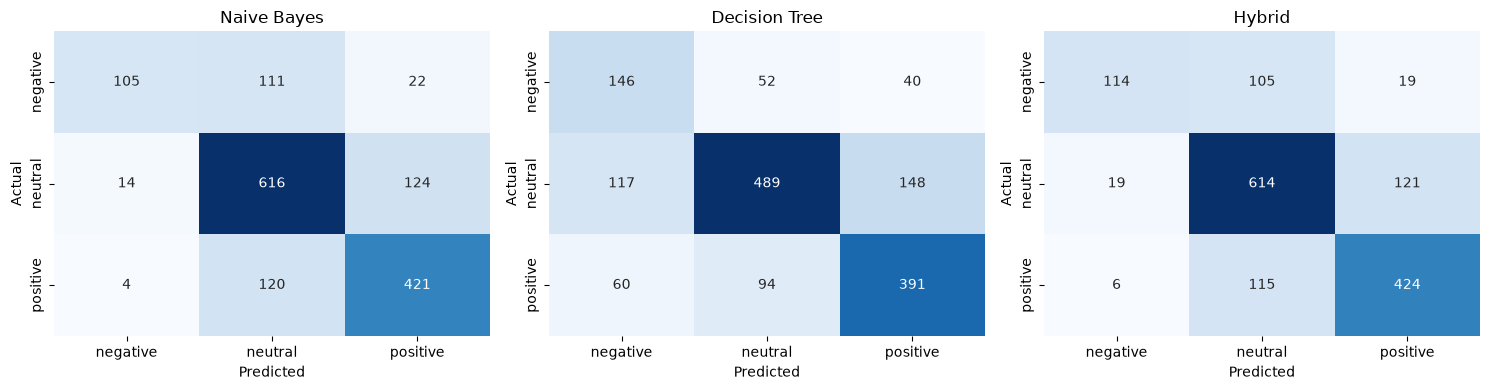

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ['negative', 'neutral', 'positive']
for ax, name, pred in zip(axes, ['Naive Bayes', 'Decision Tree', 'Hybrid'],
                          [nb_pred, dt_pred, hybrid_pred]):
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


## 11. Cross-validation on the merged training set

A single 80/20 split leaves a modest test set. 5-fold cross-validation on the
training portion gives a mean and standard deviation, so you can say whether
a difference between models is real or just the luck of one split.

Note: the training portion includes the extra Taglish/English rows, so these fold scores are a little
optimistic compared with the held-out test set above.

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, model in [('Naive Bayes', make_nb()),
                    ('Decision Tree', make_dt()),
                    ('Hybrid', make_hybrid())]:
    pipe = Pipeline([('v', CountVectorizer(ngram_range=(1,2), min_df=2)), ('c', model)])
    acc = cross_val_score(pipe, train['clean'], train['sentiment'], cv=cv, scoring='accuracy')
    f1m = cross_val_score(pipe, train['clean'], train['sentiment'], cv=cv, scoring='f1_macro')
    cv_rows.append({'Model': name,
                    'CV Accuracy': f'{acc.mean():.4f} +/- {acc.std():.4f}',
                    'CV Macro F1': f'{f1m.mean():.4f} +/- {f1m.std():.4f}'})
pd.DataFrame(cv_rows).set_index('Model')


,CV Accuracy,CV Macro F1
Model,,
Naive Bayes,0.7597 +/- 0.0082,0.7417 +/- 0.0079
Decision Tree,0.6790 +/- 0.0210,0.6677 +/- 0.0214
Hybrid,0.7600 +/- 0.0066,0.7429 +/- 0.0064


## 12. Sort feedback by sentiment priority

Negative first, then neutral, then positive.


In [15]:
SENTIMENT_PRIORITY = {'negative': 0, 'neutral': 1, 'positive': 2}

def sort_feedback(texts):
    cleaned = [preprocess(t) for t in texts]
    V = vectorizer.transform(cleaned)
    labels_ = hybrid.predict(V)
    out = pd.DataFrame({'feedback': texts, 'sentiment': labels_})
    out['priority'] = out['sentiment'].map(SENTIMENT_PRIORITY)
    return out.sort_values('priority').drop(columns='priority').reset_index(drop=True)

sample = [
    "the wifi keeps dropping on the 2nd floor quiet study area",
    "the librarian at the circulation desk was very helpful",
    "the collection has enough books but the database access is limited",
    "i never got a reply about the reserved book i requested",
    "borrowing and returning was fast and easy, thank you",
]
sort_feedback(sample)


,feedback,sentiment
0,the wifi keeps dropping on the 2nd floor quiet...,negative
1,the librarian at the circulation desk was very...,positive
2,the collection has enough books but the databa...,positive
3,i never got a reply about the reserved book i ...,positive
4,"borrowing and returning was fast and easy, tha...",positive


## 13. Library-facilities performance

This is the actual deployment target. It isolates the library-facilities
rows in the test set and reports how each model does on them specifically,
separate from the merged average above.


In [16]:
lib_mask = test['category'] == 'library_facilities'
lib_test = test[lib_mask]
lib_Xte = vectorizer.transform(lib_test['clean'])
lib_ytrue = lib_test['sentiment']

print('Library-facilities rows in test set:', len(lib_test))
print(lib_ytrue.value_counts().to_dict())
print()

for name, model in [('Naive Bayes', nb), ('Decision Tree', dt), ('Hybrid', hybrid)]:
    pred = model.predict(lib_Xte)
    acc = accuracy_score(lib_ytrue, pred)
    f1 = f1_score(lib_ytrue, pred, average='macro', zero_division=0)
    print(f'{name:15} accuracy={acc:.4f}  macro F1={f1:.4f}')

print()
print('--- Hybrid detail on library-facilities rows only ---')
lib_pred = hybrid.predict(lib_Xte)
print(classification_report(lib_ytrue, lib_pred, digits=3, zero_division=0))


Library-facilities rows in test set: 135
{'negative': 51, 'positive': 43, 'neutral': 41}

Naive Bayes     accuracy=0.9111  macro F1=0.9092
Decision Tree   accuracy=0.8000  macro F1=0.7998
Hybrid          accuracy=0.9111  macro F1=0.9104

--- Hybrid detail on library-facilities rows only ---
              precision    recall  f1-score   support

    negative      0.860     0.961     0.907        51
     neutral      1.000     0.805     0.892        41
    positive      0.911     0.953     0.932        43

    accuracy                          0.911       135
   macro avg      0.924     0.906     0.910       135
weighted avg      0.919     0.911     0.910       135

